In [1]:
import time
start_time=time.time()


VIENTO pipeline

- Velocity Field
- Structure Function B(r) computation
- B(r) fit parameter ( 3 and 5 -parameter model) and confidence intervals determination
- Comparison between different results
- See what we have, what it is needed, if works, etc.

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import save_modelresult


# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

import strucfunc                   
#import ci_results_compiler
import fit_structure_function
import bfunc
#import bplot
#import bplot_ideal

# Loading velocity field

In [3]:
# Loading 3D fake maps
name = 'fake_cube_mod_finite_sigE1_m330_r32_N512'
hdul = fits.open('fake_maps_data/' + name + '.fits')
hdr = hdul[0].header
print(hdul.info())
print(hdr)
sb = hdul['MOM0'].data.astype(float)
vv= hdul['MOM1'].data.astype(float)

Filename: fake_maps_data/fake_cube_mod_finite_sigE1_m330_r32_N512.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      18   ()      
  1  MOM0          1 ImageHDU         8   (512, 512)   float64   
  2  MOM1          1 ImageHDU         8   (512, 512)   float64   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  AUTHOR  = 'J. Garcia-Vazquez'  / File creator                                   M3D     =                  0.3 / k = 3 + m3D                                    RA      =                 32.0 / Artificial correlation length                  SIG     =  0.15674216075224537 / Standard deviation artificial map              SIG2    =  0.02456810495728273 / Varian

In [9]:
box_size = hdr['BOX_SIZE']

# Computing structure function

In [4]:
Br = strucfunc.strucfunc_numba_parallel(vv, wmap=sb, dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\pipeline_VIENTO\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\pipeline_VIENTO\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


In [5]:
class MyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)

In [6]:
# Export results from Numba structure function
data_export = {
    'strucfun_numba_parallel' : Br,
}

jsonfilename = name +".json"
with open(jsonfilename, "w") as f:
    json.dump(data_export, fp=f, indent=3, cls=MyEncoder)

# Fitting and confidence intervals

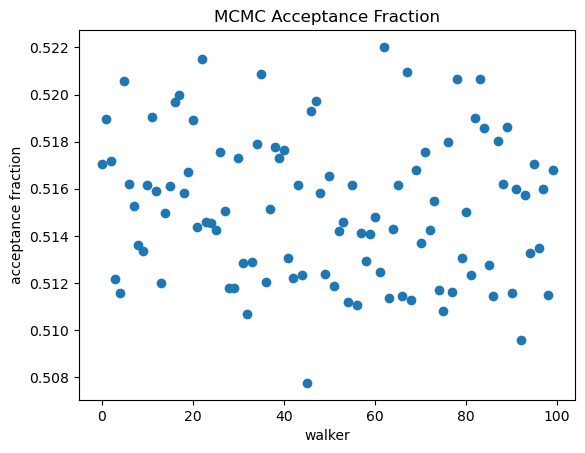

Autocorrelation time for the parameters:
----------------------------------------
r0 = 78.503
sig2 = 81.931
m = 75.990
s0 = 92.902
noise = 101.328


In [10]:
fit_Br = fit_structure_function.fit_structure_function(Br, box_size, bfunc, name = 'Br', data = 'Br')

In [11]:
fit_Br

{'result': <lmfit.model.ModelResult at 0x204e4fe46b0>,
 'result_emcee': <lmfit.model.ModelResult at 0x204e4f91f10>}

In [12]:
save_modelresult(fit_Br['result'], name + "result.sav")

In [13]:
save_modelresult(fit_Br['result_emcee'], name + "result_emcee.sav")

In [14]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 914.2227013111115 seconds ---
